In [14]:
import pandas as pd
import seaborn as sns 
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris


In [15]:
iris = load_iris() 

In [18]:
x=pd.DataFrame(iris.data)
y = pd.DataFrame(iris.target)

In [19]:
from sklearn.preprocessing import StandardScaler
sclr_ = StandardScaler()

x_scaled = sclr_.fit_transform(x)

<Axes: >

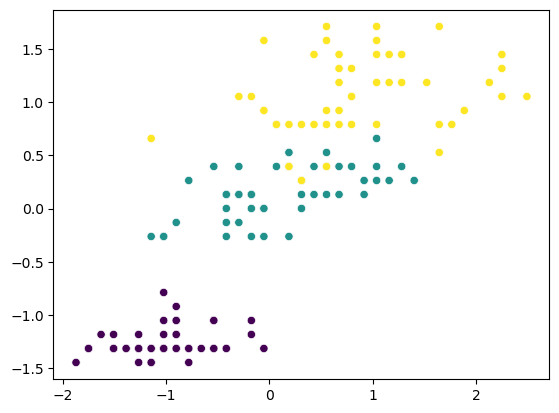

In [27]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,3],marker = 'o',c=y)

In [28]:
wscc= []

for i in range(1,20):
    k_model = KMeans(n_clusters=i)
    k_model.fit_predict(x_scaled)
    wscc.append(k_model.inertia_)

c:\Users\jinju\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jinju\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jinju\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jinju\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

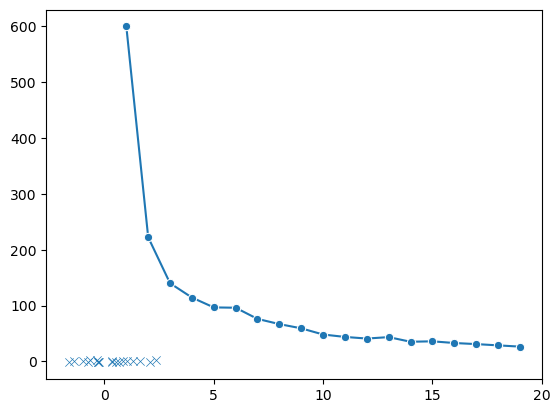

In [34]:
sns.lineplot(x=range(1,20),y=wscc,marker = 'o')


In [38]:
from kneed import KneeLocator

knee = KneeLocator(range(1,20),wscc,curve='convex',direction="decreasing")
print(knee.knee)

3


c:\Users\jinju\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

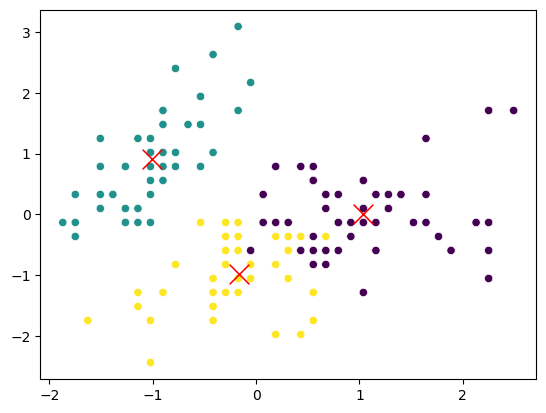

In [49]:
KMeans_m = KMeans(n_clusters=3,random_state=10)
label = KMeans_m.fit_predict(x_scaled)

sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c = label)
sns.scatterplot(x=KMeans_m.cluster_centers_[:,0],y=KMeans_m.cluster_centers_[:,1],marker = 'x',color = 'red',s = 200)